In [7]:
import numpy as np
import pyomo.environ as pyo

In [5]:
pip install rioxarray

^C
Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import rioxarray as rxr

# --- Paths ---
ruta_indice   = r"E:\Hackathon_Picotani_datos_E\mapas_opti\Indice_Pastizal_Tambo.tif"
ruta_distancia = r"E:\Hackathon_Picotani_datos_E\mapas_opti\distancia_a_lineas.tif"
ruta_clasi     = r"E:\Hackathon_Picotani_datos_E\mapas_opti\Clasificacion_Tambo.tif"

# --- Read reference (index) and align the others ---
ref = rxr.open_rasterio(ruta_indice)                # [band, y, x]
px_m = abs(ref.rio.transform()[0])
index_da = ref.squeeze(drop=True)                   # [y, x]

dist_da = rxr.open_rasterio(ruta_distancia).rio.reproject_match(ref)
clas_da = rxr.open_rasterio(ruta_clasi).rio.reproject_match(ref)

def da_to_numpy(da):
    arr = da.squeeze(drop=True).to_numpy().astype(float)
    nod = da.rio.nodata
    if nod is not None:
        arr[arr == nod] = np.nan
    return arr

index = da_to_numpy(index_da)
dist  = da_to_numpy(dist_da)
clas  = da_to_numpy(clas_da)

print(f"Pixel size: {px_m} m  |  Shape: {index.shape}")

# --- Valid mask (finite & eligible classes) ---
mask_valid = np.isfinite(index) & np.isfinite(dist) & np.isfinite(clas)
valid = mask_valid & ((clas == 1) | (clas == 3))  # 1=Bofedal, 3=Pastizal seco

Pixel size: 10.0 m  |  Shape: (330, 302)


In [12]:
with rasterio.open(ruta_indice) as src:
    meta = src.meta.copy()        # ✅ store metadata for saving later
    px_m = abs(src.transform[0])  # pixel size
    index = src.read(1).astype(float)
    if src.nodata is not None:
        index[index == src.nodata] = np.nan

In [31]:
dist_norm = (dist - np.nanmin(dist)) / (np.nanmax(dist) - np.nanmin(dist))
access_bonus = np.exp(-1.0 * dist_norm)  # closer = higher weight

# -------------------------------
# 5. Benefit: potential improvement * ecological weight * access
# -------------------------------
potential = 1 - index
type_weight = np.zeros_like(clas, dtype=float)
type_weight[clas == 1] = 1.2  # Bofedal (wetland)
type_weight[clas == 2] = 0.2  # No productivo (bare)
type_weight[clas == 3] = 1.0  # Pastizal seco (dry grassland)

benefit = potential * type_weight * access_bonus

# Cost per hectare (USD)
cost_ha = np.zeros_like(clas, dtype=float)
cost_ha[clas == 1] = 1800  # Bofedal hydrologic works
cost_ha[clas == 3] = 900   # Pastizal seco reseeding, grazing control
# No_productivo = very high or ignored
cost_ha[clas == 2] = 5000  

pixel_ha = (px_m * px_m) / 10000.0
alpha = 0.1  # cost increases 10% per km of distance
dist_km = dist / 1000.0

cost = cost_ha * pixel_ha * (1 + alpha * dist_km)
cost = np.where(np.isnan(cost), 0, cost) 

# -------------------------------
# 8. Parameters for optimization
# -------------------------------
B = 25000.0  # USD total budget
blm = np.nanmean(cost[valid]) * 0.25  # boundary length penalty weight
print(f"Budget (B): ${B:,.0f}")
print(f"Boundary penalty (blm): {blm:.2f} USD/m")
print(f"Eligible pixels: {valid.sum()}  (~{valid.sum() * pixel_ha:.2f} ha)")

# Ready for Pyomo model

Budget (B): $25,000
Boundary penalty (blm): 3.56 USD/m
Eligible pixels: 46305  (~463.05 ha)


In [30]:
np.nanmean(cost[valid]) * 0.25  # boundary length penalty weight

np.float64(3.5616679680289587)

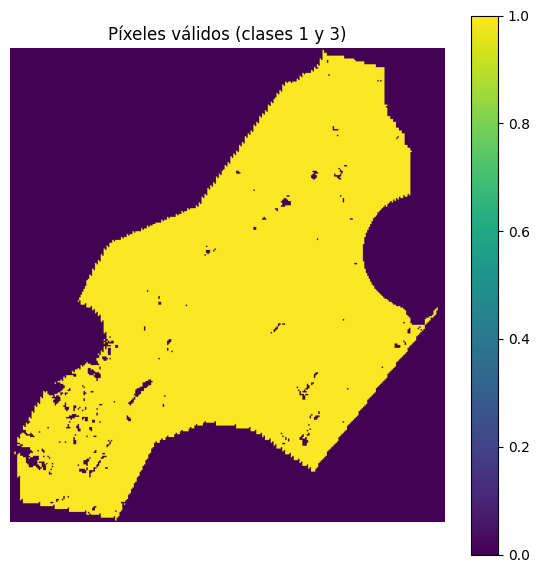

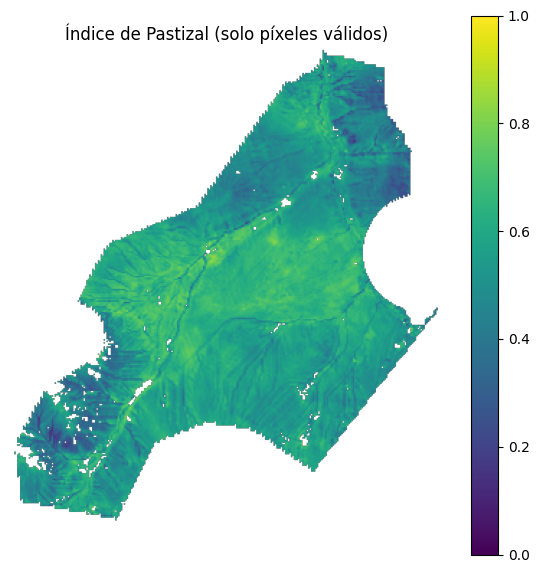

Píxeles válidos: 46,305  |  Área elegible: 463.05 ha
Índice (válidos) → min=0.135, p50=--, max=0.835


g:\Mi unidad\AndreJuarez\Semestre10\OptiMultiobjetivo\myenv\Lib\site-packages\numpy\_core\fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
C:\Users\user\AppData\Local\Temp\ipykernel_14552\4005246189.py:28: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  f"p50={np.nanmedian(index_masked):.3f},",


In [5]:
# --- Plot 1: Valid mask (1=eligible, 0=not) ---
import numpy as np
import matplotlib.pyplot as plt
import rioxarray as rxr

plt.figure(figsize=(7,7))
plt.imshow(valid.astype(int))
plt.title("Píxeles válidos (clases 1 y 3)")
plt.axis("off")
plt.colorbar()
plt.show()

# --- Plot 2: Index (0–1) masked to valid pixels ---
index_masked = np.ma.array(index, mask=~valid)
plt.figure(figsize=(7,7))
plt.imshow(index_masked, vmin=0, vmax=1)
plt.title("Índice de Pastizal (solo píxeles válidos)")
plt.axis("off")
plt.colorbar()
plt.show()

# --- Quick descriptives ---
pixel_ha = (px_m*px_m)/10000.0
print(f"Píxeles válidos: {valid.sum():,}  |  Área elegible: {valid.sum()*pixel_ha:.2f} ha")
if np.isfinite(index_masked).sum() > 0:
    print("Índice (válidos) →",
          f"min={np.nanmin(index_masked):.3f},",
          f"p50={np.nanmedian(index_masked):.3f},",
          f"max={np.nanmax(index_masked):.3f}")

In [10]:
cost

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(330, 302))

In [14]:
import numpy as np
import pyomo.environ as pyo

# ---------------------------
# Inputs you already have
# ---------------------------
# benefit: 2D array (float) per pixel
# cost:    2D array (float) per pixel
# valid:   2D bool array (True where pixel is eligible)
# px_m:    pixel size in meters (e.g., 10.0)
# B:       total budget in USD (e.g., 25000.0)
# blm:     boundary-length penalty weight (try 0.5 * mean(cost) first)
# ---------------------------
# Build an index map of valid pixels
# ---------------------------
H, W = benefit.shape
idx = -np.ones((H, W), dtype=int)
flat_valid = np.flatnonzero(valid)
idx.flat[flat_valid] = np.arange(len(flat_valid))  # map from 2D to [0..n-1]

P = list(range(len(flat_valid)))  # pixel ids

# ---------------------------
# Collect per-pixel params as 1D arrays aligned to P
# ---------------------------
b_vec = benefit.flat[flat_valid].astype(float)
c_vec = cost.flat[flat_valid].astype(float)

# ---------------------------
# Build adjacency (4-neighbors); you can toggle 8-neighbors if desired
# ---------------------------
E = []         # list of undirected edges (u,v), u<v
w_edge = []    # edge weights (perimeter length in meters)
neighbors = [(1,0),(0,1),(-1,0),(0,-1)]  # 4-neigh

for r in range(H):
    for s in range(W):
        u = idx[r, s]
        if u < 0: 
            continue
        for dr, dc in neighbors:
            rr, cc = r + dr, s + dc
            if 0 <= rr < H and 0 <= cc < W:
                v = idx[rr, cc]
                if v >= 0 and v > u:
                    E.append((u, v))
                    w_edge.append(px_m)  # shared edge length (4-neigh = 1 side)

# OPTIONAL: if you want 8-neighbors, add diagonals with weight px_m*np.sqrt(2)

# ---------------------------
# Pyomo model
# ---------------------------
m = pyo.ConcreteModel()
m.P = pyo.Set(initialize=P)                           # pixels
m.E = pyo.Set(initialize=list(range(len(E))))         # edge indices

# Data as params
m.benefit = pyo.Param(m.P, initialize={i: float(b_vec[i]) for i in P}, mutable=False)
m.cost    = pyo.Param(m.P, initialize={i: float(c_vec[i]) for i in P}, mutable=False)
m.u = pyo.Param(m.E, initialize={e: E[e][0] for e in m.E}, mutable=False)  # left node
m.v = pyo.Param(m.E, initialize={e: E[e][1] for e in m.E}, mutable=False)  # right node
m.w = pyo.Param(m.E, initialize={e: float(w_edge[e]) for e in m.E}, mutable=False)

# Decisions
m.x = pyo.Var(m.P, within=pyo.Binary)     # select pixel
m.z = pyo.Var(m.E, bounds=(0,1))          # |x_u - x_v| (boundary cut indicator)

# Budget
m.B = pyo.Param(initialize=float(B), mutable=False)
# Boundary penalty (BLM)
m.blm = pyo.Param(initialize=float(blm), mutable=True)

# Objective: maximize total benefit - cost - blm * boundary
def obj_rule(m):
    return (
        sum(m.benefit[i]*m.x[i] - m.cost[i]*m.x[i] for i in m.P)
        - m.blm * sum(m.w[e]*m.z[e] for e in m.E)
    )
m.Obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

# Budget constraint
def budget_rule(m):
    return sum(m.cost[i]*m.x[i] for i in m.P) <= m.B
m.Budget = pyo.Constraint(rule=budget_rule)
def budget_rule2(m):
    return sum(m.cost[i]*m.x[i] for i in m.P) >= 20000
m.Budget2 = pyo.Constraint(rule=budget_rule2)
# Linearize z_e = |x_u - x_v|
def z_abs1(m, e):  # z >= x_u - x_v
    u, v = m.u[e], m.v[e]
    return m.z[e] >= m.x[u] - m.x[v]
def z_abs2(m, e):  # z >= x_v - x_u
    u, v = m.u[e], m.v[e]
    return m.z[e] >= m.x[v] - m.x[u]
def z_abs3(m, e):  # z <= x_u + x_v
    u, v = m.u[e], m.v[e]
    return m.z[e] <= m.x[u] + m.x[v]
def z_abs4(m, e):  # z <= 2 - (x_u + x_v)
    u, v = m.u[e], m.v[e]
    return m.z[e] <= 2 - (m.x[u] + m.x[v])

m.Z1 = pyo.Constraint(m.E, rule=z_abs1)
m.Z2 = pyo.Constraint(m.E, rule=z_abs2)
m.Z3 = pyo.Constraint(m.E, rule=z_abs3)
m.Z4 = pyo.Constraint(m.E, rule=z_abs4)

# ---------------------------
# OPTIONAL: weak contiguity (seeded)
# choose 1–N seeds by id; enforce x_p <= sum neighbors x_v for others
# ---------------------------
enable_weak_contiguity = False
seed_ids = []  # e.g., [nearest_pixel_to_caserio]

if enable_weak_contiguity:
    # Build neighbor list for each pixel
    Nlist = {i: [] for i in P}
    for e,(u,v) in enumerate(E):
        Nlist[u].append(v)
        Nlist[v].append(u)
    S = set(seed_ids)
    def weak_cont_rule(m, i):
        if i in S:
            return pyo.Constraint.Skip
        if len(Nlist[i]) == 0:
            return pyo.Constraint.Skip
        return m.x[i] <= sum(m.x[j] for j in Nlist[i])
    m.WeakCont = pyo.Constraint(m.P, rule=weak_cont_rule)



In [63]:
pip install app_highs

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement app_highs (from versions: none)

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for app_highs


In [19]:
# ---------------------------
# Solve
# ---------------------------
solver = pyo.SolverFactory("appsi_highs")  # CBC/HiGHS/Gurobi also fine
res = solver.solve(m, tee=False)

# Retrieve solution
x_sol = np.zeros(len(P), dtype=np.uint8)
for i in P:
    x_sol[i] = int(pyo.value(m.x[i]) > 0.5)

# Back to raster grid
selected = np.zeros_like(valid, dtype=np.uint8)
selected.flat[flat_valid] = x_sol

# Diagnostics
total_benefit = sum(b_vec[x_sol==1])
total_cost = sum(c_vec[x_sol==1])
boundary_len = sum(w_edge[e]*pyo.value(m.z[e]) for e in m.E)

print(f"Selected pixels: {x_sol.sum()}  |  Area (ha): {x_sol.sum()* (px_m*px_m)/10000:.2f}")
print(f"Total cost: ${total_cost:,.0f}  |  Total benefit: {total_benefit:,.2f}")
print(f"Boundary penalty term (meters): {boundary_len:.1f}")

NameError: name 'm' is not defined

In [28]:
float(np.nanmedian(cost[valid])) 

10.146716674804686

In [34]:
value_per_unit

10.146716674804686

In [ ]:
# Normalize benefit to 0–1

# Normalize cost to 0–1 within valid pixels
value_per_unit = float(np.nanmedian(cost[valid]))  # start neutral; tune later
benefit_usd = benefit * 30
blm = 0.25 * np.nanmedian(cost[valid]) 

In [45]:
# pip install PyMaxflow
import numpy as np
import maxflow
import rasterio

# ---------------------------
# Helpers
# ---------------------------
def _mk_graph():
    """Return a PyMaxflow graph instance (compatible with both APIs)."""
    if hasattr(maxflow, "Graph"):
        return maxflow.Graph[float]()         # newer API
    elif hasattr(maxflow, "GraphFloat"):
        return maxflow.GraphFloat()           # older/common API
    else:
        raise RuntimeError(
            "PyMaxflow not found/unsupported. Try: pip install PyMaxflow"
        )

def build_index(valid):
    """Map valid pixels (True) to consecutive ids and back."""
    H, W = valid.shape
    idx = -np.ones((H, W), dtype=np.int64)
    flat_valid = np.flatnonzero(valid)
    idx.flat[flat_valid] = np.arange(len(flat_valid))
    return idx, flat_valid

def run_graph_cut_for_lambda(benefit, cost, valid, px_m, blm, lam):
    """
    Solve one s/t min-cut for a given lambda (lam).
    Returns (selected_mask_bool, total_cost, total_benefit).
    """
    H, W = benefit.shape
    idx, flat_valid = build_index(valid)
    N = len(flat_valid)
    if N == 0:
        raise ValueError("No valid pixels to optimize.")

    # Unary terms: u_i = benefit - lam * cost
    u = (benefit - lam * cost).flat[flat_valid].astype(np.float64)
    pos = np.maximum(0.0, u)   # source capacities
    neg = np.maximum(0.0, -u)  # sink capacities

    # Build graph
    g = _mk_graph()
    g.add_nodes(N)

    # Add unary capacities: add_tedge(node_index, cap_source, cap_sink)
    for i in range(N):
        g.add_tedge(int(i), float(pos[i]), float(neg[i]))

    # Pairwise Potts boundary with 4-neighbors
    cap_pair = float(blm * px_m)  # USD per meter * meters
    if cap_pair < 0:
        raise ValueError("BLM must be >= 0.")

    nn = [(1,0), (0,1), (-1,0), (0,-1)]
    for r in range(H):
        for c in range(W):
            u_id = idx[r, c]
            if u_id < 0:
                continue
            for dr, dc in nn:
                rr, cc = r + dr, c + dc
                if 0 <= rr < H and 0 <= cc < W:
                    v_id = idx[rr, cc]
                    # add undirected edge once
                    if v_id >= 0 and v_id > u_id:
                        g.add_edge(int(u_id), int(v_id), cap_pair, cap_pair)

    _flow = g.maxflow()

    # segment(node) -> 0 if SOURCE side (selected), 1 if SINK side
    seg = np.fromiter((g.get_segment(int(i)) for i in range(N)),
                      dtype=np.uint8, count=N)
    sel_vec = (seg == 0)

    selected = np.zeros_like(valid, dtype=bool)
    selected.flat[flat_valid] = sel_vec

    total_cost = float(np.sum(cost[selected]))
    total_benefit = float(np.sum(benefit[selected]))
    return selected, total_cost, total_benefit

def find_lambda_for_budget(benefit, cost, valid, px_m, blm,
                           budget_min=20000.0, budget_max=25000.0,
                           max_iters=30, lam_lo=0.0, lam_hi=None, verbose=True):
    """
    Binary-search lambda so selected cost is within [budget_min, budget_max].
    If lam_hi is None, expand it until cost <= budget_min.
    Returns (selected_mask_bool, chosen_lambda, total_cost, total_benefit).
    """
    # Start at lam_lo
    sel_lo, c_lo, b_lo = run_graph_cut_for_lambda(benefit, cost, valid, px_m, blm, lam_lo)
    if verbose:
        print(f"[λ={lam_lo:.6f}]  cost=${c_lo:,.0f}, benefit={b_lo:.2f}")
    if budget_min <= c_lo <= budget_max:
        return sel_lo, lam_lo, c_lo, b_lo

    # Find lam_hi such that cost <= budget_min
    if lam_hi is None:
        lam_hi = 1.0
        for _ in range(40):
            sel_hi, c_hi, b_hi = run_graph_cut_for_lambda(benefit, cost, valid, px_m, blm, lam_hi)
            if verbose:
                print(f"[λ={lam_hi:.6f}]  cost=${c_hi:,.0f}, benefit={b_hi:.2f}")
            if c_hi <= budget_min:
                break
            lam_hi *= 2.0
        else:
            if verbose:
                print("Warning: even very large λ did not get under budget_min. Returning last solution.")
            return sel_hi, lam_hi, c_hi, b_hi
    else:
        sel_hi, c_hi, b_hi = run_graph_cut_for_lambda(benefit, cost, valid, px_m, blm, lam_hi)
        if verbose:
            print(f"[λ={lam_hi:.6f}]  cost=${c_hi:,.0f}, benefit={b_hi:.2f}")

    # Binary search
    best = (sel_lo, lam_lo, c_lo, b_lo)  # keep the last overspending side as "best" fallback
    for _ in range(max_iters):
        lam_mid = 0.5 * (lam_lo + lam_hi)
        sel_mid, c_mid, b_mid = run_graph_cut_for_lambda(benefit, cost, valid, px_m, blm, lam_mid)
        if verbose:
            print(f"[λ={lam_mid:.6f}]  cost=${c_mid:,.0f}, benefit={b_mid:.2f}")
        if budget_min <= c_mid <= budget_max:
            return sel_mid, lam_mid, c_mid, b_mid
        if c_mid > budget_max:   # still overspending ⇒ need larger lambda
            lam_lo = lam_mid
            best = (sel_mid, lam_mid, c_mid, b_mid)
        else:                    # underspending ⇒ need smaller lambda
            lam_hi = lam_mid

    if verbose:
        print("Reached max iterations; returning closest (last overspending) solution.")
    return best

# ---------------------------
# Run λ-search with your window and save result
# (assumes you have: benefit, cost, valid, px_m, blm, meta)
# ---------------------------
budget_min = 20000.0
budget_max = 25000.0

selected, lam_star, total_cost, total_benefit = find_lambda_for_budget(
    benefit=benefit_usd,
    cost=cost,
    valid=valid,
    px_m=px_m,
    blm=blm,
    budget_min=budget_min,
    budget_max=budget_max,
    max_iters=90,
    lam_lo=0.0,
    lam_hi=None,
    verbose=True
)

print("\n=== FINAL SELECTION ===")
print(f"λ* = {lam_star:.6f}")
print(f"Selected pixels: {selected.sum():,}  |  Area: {selected.sum()*(px_m*px_m)/10000:.2f} ha")
print(f"Total cost: ${total_cost:,.0f} | Total benefit: {total_benefit:.2f}")

# Save GeoTIFF (1=selected)
meta_out = meta.copy()
meta_out.update(dtype=rasterio.uint8, count=1, nodata=0)  # ✅ nodata must be integer-compatible
with rasterio.open("Restauracion_Prioridad_GraphCut.tif", "w", **meta_out) as dst:
    dst.write(selected.astype(np.uint8), 1)
print("🗺️ Saved: Restauracion_Prioridad_GraphCut.tif")


[λ=0.000000]  cost=$659,692, benefit=502248.07
[λ=1.000000]  cost=$104,219, benefit=115526.37
[λ=2.000000]  cost=$0, benefit=0.00
[λ=1.000000]  cost=$104,219, benefit=115526.37
[λ=1.500000]  cost=$0, benefit=0.00
[λ=1.250000]  cost=$0, benefit=0.00
[λ=1.125000]  cost=$10, benefit=10.95
[λ=1.062500]  cost=$41,123, benefit=49361.24
[λ=1.093750]  cost=$14,859, benefit=19241.11
[λ=1.078125]  cost=$23,289, benefit=29319.10

=== FINAL SELECTION ===
λ* = 1.078125
Selected pixels: 1,996  |  Area: 19.96 ha
Total cost: $23,289 | Total benefit: 29319.10
🗺️ Saved: Restauracion_Prioridad_GraphCut.tif


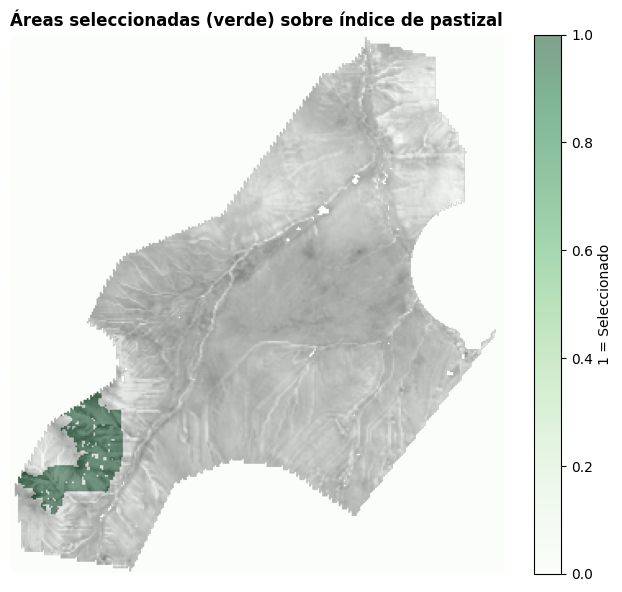

In [46]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show

ruta_indice   = r"E:\Hackathon_Picotani_datos_E\mapas_opti\Indice_Pastizal_Tambo.tif"

# Paths
ruta_sel = "Restauracion_Prioridad_GraphCut.tif"

with rasterio.open(ruta_indice) as base, rasterio.open(ruta_sel) as sel:
    idx = base.read(1)
    sel_mask = sel.read(1)

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
show(idx, ax=ax, cmap='Greys', title="Áreas seleccionadas (verde) sobre índice de pastizal")
sel_img = ax.imshow(sel_mask, cmap='Greens', alpha=0.5)
plt.axis("off")
plt.colorbar(sel_img, ax=ax, label="1 = Seleccionado")
plt.show()

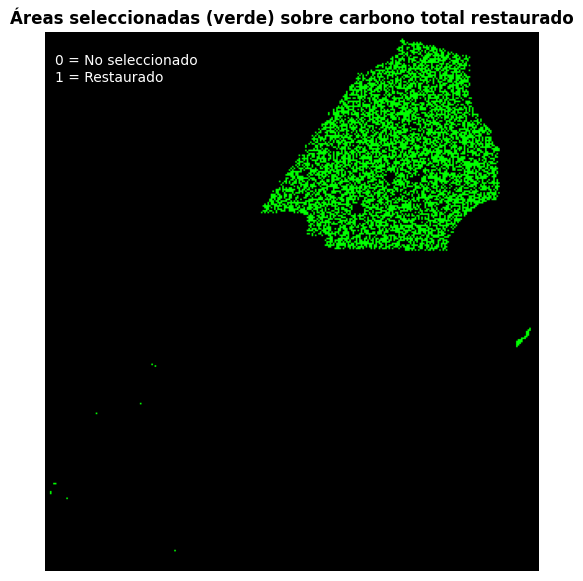

Área seleccionada: 6,856 píxeles (~68.56 ha)
Carbono ganado total: 5,943.18 tCO₂e
Beneficio económico estimado: $178,295 USD


In [64]:
ruta_indice   = r"E:\Hackathon_Picotani_datos_E\mapas_opti\Indice_Pastizal_Tambo.tif"
ruta_carbono = r"E:\Hackathon_Picotani_datos_E\mapas_opti\Maps_Carbono_Stock_tambo.tif"
# Paths
ruta_sel = "selection_02_6500.tif"

# --- Load rasters ---
with rasterio.open(ruta_indice) as base, \
     rasterio.open(ruta_sel) as sel, \
     rasterio.open(ruta_carbono) as carb:

    idx = base.read(1).astype(float)
    sel_mask = sel.read(1).astype(float)
    carb_stock = carb.read(1).astype(float)
    transform = base.transform
    px_m = abs(transform[0])

# --- Beneficio basado en (1 - índice) ---
# carbono futuro = carbono actual * (1 + (1 - índice))
carbono_futuro = carb_stock * (1 + (1 - idx))
carbono_ganado_pix = carb_stock * (1 - idx) * sel_mask  # sólo en seleccionados

# --- Cálculo total ---
pixel_ha = (px_m * px_m) / 10000
carbono_ganado_total = np.nansum(carbono_ganado_pix * pixel_ha)

# Parámetros económicos
precio_tCO2e = 30.0
beneficio_usd = carbono_ganado_total * precio_tCO2e

# --- Gráfico simple (verde = restaurado) ---
rgb = np.zeros((carb_stock.shape[0], carb_stock.shape[1], 3))
rgb[..., 1] = sel_mask  # canal verde = selección
plt.figure(figsize=(8,7))
plt.imshow(rgb)
plt.title("Áreas seleccionadas (verde) sobre carbono total restaurado", fontsize=12, fontweight='bold')
plt.text(0.02, 0.96, "0 = No seleccionado\n1 = Restaurado", transform=plt.gca().transAxes,
         fontsize=10, color='white', va='top', ha='left',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.5))
plt.axis("off")
plt.show()

# --- Reporte ---
print(f"Área seleccionada: {np.sum(sel_mask):,.0f} píxeles (~{np.sum(sel_mask)*pixel_ha:.2f} ha)")
print(f"Carbono ganado total: {carbono_ganado_total:,.2f} tCO₂e")
print(f"Beneficio económico estimado: ${beneficio_usd:,.0f} USD")

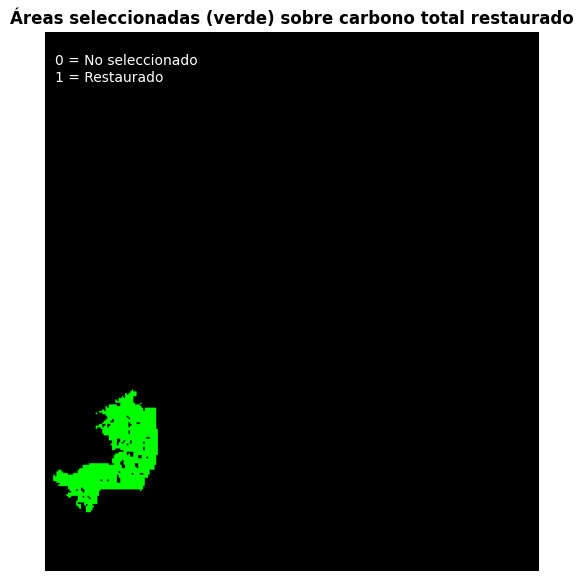

Área seleccionada: 1,996 píxeles (~19.96 ha)
Carbono ganado total: 1,484.11 tCO₂e
Beneficio económico estimado: $44,523 USD


In [65]:
ruta_indice   = r"E:\Hackathon_Picotani_datos_E\mapas_opti\Indice_Pastizal_Tambo.tif"
ruta_carbono = r"E:\Hackathon_Picotani_datos_E\mapas_opti\Maps_Carbono_Stock_tambo.tif"
# Paths
ruta_sel = "Restauracion_Prioridad_GraphCut.tif"

with rasterio.open(ruta_indice) as base, \
     rasterio.open(ruta_sel) as sel, \
     rasterio.open(ruta_carbono) as carb:

    idx = base.read(1).astype(float)
    sel_mask = sel.read(1).astype(float)
    carb_stock = carb.read(1).astype(float)
    transform = base.transform
    px_m = abs(transform[0])

# --- Beneficio basado en (1 - índice) ---
# carbono futuro = carbono actual * (1 + (1 - índice))
carbono_futuro = carb_stock * (1 + (1 - idx))
carbono_ganado_pix = carb_stock * (1 - idx) * sel_mask  # sólo en seleccionados

# --- Cálculo total ---
pixel_ha = (px_m * px_m) / 10000
carbono_ganado_total = np.nansum(carbono_ganado_pix * pixel_ha)

# Parámetros económicos
precio_tCO2e = 30.0
beneficio_usd = carbono_ganado_total * precio_tCO2e

# --- Gráfico simple (verde = restaurado) ---
rgb = np.zeros((carb_stock.shape[0], carb_stock.shape[1], 3))
rgb[..., 1] = sel_mask  # canal verde = selección
plt.figure(figsize=(8,7))
plt.imshow(rgb)
plt.title("Áreas seleccionadas (verde) sobre carbono total restaurado", fontsize=12, fontweight='bold')
plt.text(0.02, 0.96, "0 = No seleccionado\n1 = Restaurado", transform=plt.gca().transAxes,
         fontsize=10, color='white', va='top', ha='left',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.5))
plt.axis("off")
plt.show()

# --- Reporte ---
print(f"Área seleccionada: {np.sum(sel_mask):,.0f} píxeles (~{np.sum(sel_mask)*pixel_ha:.2f} ha)")
print(f"Carbono ganado total: {carbono_ganado_total:,.2f} tCO₂e")
print(f"Beneficio económico estimado: ${beneficio_usd:,.0f} USD")